In [33]:
# Cell 1: imports and paths

import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

PROJ_ROOT = Path("~").expanduser() / "Desktop" / "shockley_repo"
DATA = PROJ_ROOT / "data"
FIGURES = PROJ_ROOT / "figures" / "figures_GRWs" / "naive" / "figures_NAIVE_GRW_Y"
RESULTS = PROJ_ROOT / "results" / "results_GRWs" / "naive" / "results_NAIVE_GRW_Y"

FIGURES.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)


In [34]:
# Cell 2: analysis settings

EPS = 0.49
N = 50000
Y = 20
SEED = 63

rng = np.random.default_rng(SEED)

In [35]:
# Cell 3: load data

df_original = pd.read_csv(DATA / "adjusted_productivity.csv")

print(df_original.shape)
df_original.head()

(54948, 21)


,contribs,contribs_with_corr,current,dblp,department,facultyName,first_asst_job_rank,first_asst_job_year,has_postdoc,is_female,...,phd_rank,phd_year,place,pubs,pubs_adj,pubs_with_corr,pubs_with_corr_adj,recordDate,year,CareerAge
0,0.342857,0.342857,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,2,3.902057,2,3.902057,6/6/11,1998,-3
1,0.250000,0.250000,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,1,1.875160,1,1.875160,6/6/11,1999,-2
2,1.833333,1.833333,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,4,7.214900,4,7.214900,6/6/11,2000,-1
3,1.583333,1.583333,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,3,5.209137,3,5.209137,6/6/11,2001,0
4,1.444444,1.444444,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,28.65,2001.0,Brown University,4,6.691238,4,6.691238,6/6/11,2002,1


In [36]:
# Cell 4: build empirical panel

df_original["dblp_id"] = df_original["dblp"] + df_original["phd_year"].astype(str)
working_df = df_original.sort_values(["dblp_id", "CareerAge"]).copy()

working_df["log_pubs_adj"] = np.log(working_df["pubs_adj"] + EPS)

working_df["pubs_adj_next"] = working_df.groupby("dblp_id")["pubs_adj"].shift(-1)
working_df["CareerAge_next"] = working_df.groupby("dblp_id")["CareerAge"].shift(-1)
working_df["log_pubs_next"] = working_df.groupby("dblp_id")["log_pubs_adj"].shift(-1)

working_df["log_delta"] = working_df["log_pubs_next"] - working_df["log_pubs_adj"]

is_next_year = working_df["CareerAge_next"].eq(working_df["CareerAge"] + 1)
is_in_window = working_df["CareerAge"].between(0, Y - 1)

working_df_fit = (
    working_df[is_next_year & is_in_window]
    .dropna(subset=["log_pubs_adj", "log_pubs_next", "log_delta"])
    .copy()
)

print("all rows:", len(working_df))
print("next-year transitions:", is_next_year.sum())
print("in transition window:", is_in_window.sum())
print("fit rows:", len(working_df_fit))
working_df_fit.head()


all rows: 54948
next-year transitions: 52503
in transition window: 36169
fit rows: 34701


,contribs,contribs_with_corr,current,dblp,department,facultyName,first_asst_job_rank,first_asst_job_year,has_postdoc,is_female,...,pubs_with_corr_adj,recordDate,year,CareerAge,dblp_id,log_pubs_adj,pubs_adj_next,CareerAge_next,log_pubs_next,log_delta
3,1.583333,1.583333,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,5.209137,6/6/11,2001,0,=Ccedil=etintemel:Ugur2001.0,1.740315,6.691238,1.0,1.971472,0.231157
4,1.444444,1.444444,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,6.691238,6/6/11,2002,1,=Ccedil=etintemel:Ugur2001.0,1.971472,12.901876,2.0,2.594648,0.623176
5,1.433135,1.433135,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,12.901876,6/6/11,2003,2,=Ccedil=etintemel:Ugur2001.0,2.594648,4.667694,3.0,1.640490,-0.954159
6,1.083333,1.083333,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,4.667694,6/6/11,2004,3,=Ccedil=etintemel:Ugur2001.0,1.640490,12.016541,4.0,2.526252,0.885762
7,2.103846,2.103846,Associate Professor,=Ccedil=etintemel:Ugur,Computer Science,Ugur Cetintemel,21.92,2001,False,False,...,12.016541,6/6/11,2005,4,=Ccedil=etintemel:Ugur2001.0,2.526252,11.608251,5.0,2.493061,-0.033191


In [37]:
# Cell 5: career years

obs_years = np.arange(0, Y + 1)
transition_years = np.arange(0, Y)

print("Prod obs by career year:")
print(
    working_df.loc[working_df["CareerAge"].between(0, Y), "CareerAge"]
    .value_counts()
    .sort_index()
    .reindex(obs_years)
)
print()
print("Trans obs by starting career year:")
print(
    working_df_fit["CareerAge"]
    .value_counts()
    .sort_index()
    .reindex(transition_years)
)


Prod obs by career year:
CareerAge
0     2069
1     2149
2     2208
3     2252
4     2283
5     2277
6     2214
7     2156
8     2074
9     1992
10    1903
11    1823
12    1713
13    1609
14    1497
15    1373
16    1275
17    1178
18    1096
19    1028
20     957
Name: count, dtype: int64

Trans obs by starting career year:
CareerAge
0     2067
1     2143
2     2202
3     2247
4     2259
5     2200
6     2142
7     2059
8     1985
9     1895
10    1814
11    1710
12    1599
13    1493
14    1367
15    1271
16    1174
17    1094
18    1023
19     957
Name: count, dtype: int64


In [38]:
# Cell 6: log-prod params by career year

year_logprod_rows = []

for year in obs_years:
    subset = working_df[working_df["CareerAge"] == year]
    vals = subset["log_pubs_adj"].dropna()

    year_logprod_rows.append({
        "year": year,
        "n": len(vals),
        "mean_log_productivity": vals.mean(),
        "var_log_productivity": vals.var(ddof=0),
        "sd_log_productivity": vals.std(ddof=0),
    })

year_logprod_params = pd.DataFrame(year_logprod_rows)
year_logprod_params


,year,n,mean_log_productivity,var_log_productivity,sd_log_productivity
0,0,2069,1.096164,1.169240,1.081314
1,1,2149,1.143948,1.206474,1.098396
2,2,2208,1.420733,1.146156,1.070587
3,3,2252,1.597963,1.111421,1.054239
4,4,2283,1.649832,1.152084,1.073352
5,5,2277,1.685266,1.157075,1.075674
6,6,2214,1.630428,1.173957,1.083493
7,7,2156,1.587435,1.151704,1.073175
8,8,2074,1.510005,1.208534,1.099334
9,9,1992,1.494018,1.177235,1.085005


In [39]:
# Cell 7: fit global, yearwise naive log-delta models

def fit_log_delta(subset):
    vals = subset["log_delta"].dropna().to_numpy()

    mu, sigma = stats.norm.fit(vals)
    var = sigma**2

    return {
        "n": len(vals),
        "mean_log_delta": mu,
        "sigma_log_delta": sigma,
        "var_log_delta": var,
        "sample_mean_log_delta": vals.mean(),
        "sample_sd_log_delta": vals.std(ddof=0),
    }


global_delta_params = pd.DataFrame([{"model": "global", **fit_log_delta(working_df_fit)}])

year_delta_rows = []

for year in transition_years:
    subset = working_df_fit[working_df_fit["CareerAge"] == year].copy()
    year_delta_rows.append({"year": year, **fit_log_delta(subset)})

year_delta_params = pd.DataFrame(year_delta_rows)

print("Global naive log-delta")
display(global_delta_params)

print("Yearwise naive log-delta")
display(year_delta_params)


Global naive log-delta


,model,n,mean_log_delta,sigma_log_delta,var_log_delta,sample_mean_log_delta,sample_sd_log_delta
0,global,34701,0.006178,1.057624,1.118569,0.006178,1.057624


Yearwise naive log-delta


,year,n,mean_log_delta,sigma_log_delta,var_log_delta,sample_mean_log_delta,sample_sd_log_delta
0,0,2067,0.028980,1.259683,1.586803,0.028980,1.259683
1,1,2143,0.268758,1.196293,1.431118,0.268758,1.196293
2,2,2202,0.173335,1.081619,1.169899,0.173335,1.081619
3,3,2247,0.051549,1.050041,1.102587,0.051549,1.050041
4,4,2259,0.027380,1.044818,1.091644,0.027380,1.044818
5,5,2200,-0.063831,1.057698,1.118724,-0.063831,1.057698
6,6,2142,-0.053350,1.014904,1.030030,-0.053350,1.014904
7,7,2059,-0.089495,1.043648,1.089201,-0.089495,1.043648
8,8,1985,-0.025281,1.031750,1.064507,-0.025281,1.031750
9,9,1895,-0.060497,1.019692,1.039773,-0.060497,1.019692


In [40]:
# Cell 8: fit init prod model

q0_empirical = working_df.loc[working_df["CareerAge"] == 0, "pubs_adj"].dropna()

alpha_q0 = q0_empirical.mean()

z0_empirical = np.log(q0_empirical + EPS)
mu0_log, sigma0_log = stats.norm.fit(z0_empirical)

print("Exponential q0 scale alpha:", alpha_q0)
print("Log corrected q0 mu:", mu0_log)
print("Log corrected q0 sigma:", sigma0_log)


Exponential q0 scale alpha: 4.3046789420568725
Log corrected q0 mu: 1.0961637068079475
Log corrected q0 sigma: 1.0813141615549793


In [41]:
# Cell 9: simulation helpers

def make_naive_year_lookup(year_delta_params):
    return (
        year_delta_params
        .set_index("year")[["mean_log_delta", "sigma_log_delta"]]
        .to_dict("index")
    )


naive_year_lookup = make_naive_year_lookup(year_delta_params)


def simulate_year_log_naive(naive_year_lookup, n=N, Y=Y, q0_model="exponential", rng=None):
    if rng is None:
        rng = np.random.default_rng()

    trajectories = []

    if q0_model == "exponential":
        q0 = rng.exponential(scale=alpha_q0, size=n)
        z = np.log(q0 + EPS)

    elif q0_model == "log_corrected":
        z = rng.normal(loc=mu0_log, scale=sigma0_log, size=n)
        q0 = np.maximum(np.exp(z) - EPS, 0)

    else:
        raise ValueError("choose q0_model as 'exponential' or 'log_corrected'")

    trajectories.append(q0)

    for t in range(Y):
        mu = naive_year_lookup[t]["mean_log_delta"]
        sigma = naive_year_lookup[t]["sigma_log_delta"]

        shock = rng.normal(loc=mu, scale=sigma, size=n)
        z = z + shock

        q_next = np.maximum(np.exp(z) - EPS, 0)
        trajectories.append(q_next)

    return np.array(trajectories)


def trajectories_to_dataframe_naive(trajs):
    years = np.arange(trajs.shape[0])
    ix = np.arange(trajs.shape[1])

    df_sim = pd.DataFrame({
        "CareerAge": np.repeat(years, len(ix)),
        "ix": np.tile(ix, len(years)),
        "pubs_adj": trajs.reshape(-1),
    })

    df_sim["pubs_adj_next"] = df_sim.groupby("ix")["pubs_adj"].shift(-1)
    df_sim["q_adj_delta"] = df_sim["pubs_adj_next"] - df_sim["pubs_adj"]

    df_sim["log_pubs_adj"] = np.log(df_sim["pubs_adj"] + EPS)
    df_sim["log_pubs_next"] = np.log(df_sim["pubs_adj_next"] + EPS)
    df_sim["log_delta"] = df_sim["log_pubs_next"] - df_sim["log_pubs_adj"]

    return df_sim.dropna().copy()


In [42]:
# Cell 10: simulate yearwise naive GRW

trajs_year_naive = simulate_year_log_naive(
    naive_year_lookup=naive_year_lookup,
    n=N,
    Y=Y,
    q0_model="exponential",
    rng=rng,
)

trajs = trajs_year_naive
df_trajs = trajectories_to_dataframe_naive(trajs)

print("trajectory array shape:", trajs.shape)
print()
print("sim'd log increments:")
print(df_trajs["log_delta"].describe())

print()
print("sim'd zero fractions:")
for t in [0, 5, 10, 15, 20]:
    print(f"Year {t}: {(trajs[t] == 0).mean():.4f}")


trajectory array shape: (21, 50000)

sim'd log increments:
count    1000000.000000
mean           0.054505
std            0.892993
min           -5.046081
25%           -0.411467
50%            0.000000
75%            0.526884
max            5.556134
Name: log_delta, dtype: float64

sim'd zero fractions:
Year 0: 0.0000
Year 5: 0.1776
Year 10: 0.2709
Year 15: 0.3150
Year 20: 0.3436


In [43]:
stage_spans = [
    (0, 4,  "0.70", "0-4"),
    (5, 7,  "0.78", "5-7"),
    (8, 13, "0.86", "8-13"),
    (14, 20,"0.93", "14-20")]

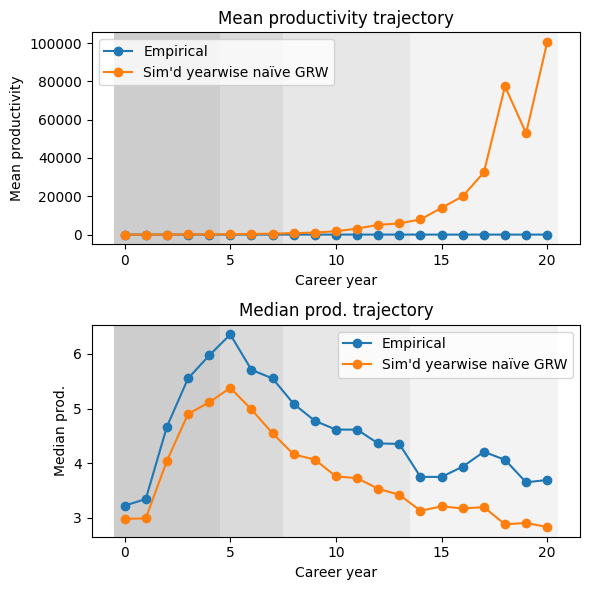

In [44]:
# Cell 11: canonical trajectory check

emp_mean = (
    working_df[working_df["CareerAge"].between(0, Y)]
    .groupby("CareerAge")["pubs_adj"]
    .mean()
)

emp_median = (
    working_df[working_df["CareerAge"].between(0, Y)]
    .groupby("CareerAge")["pubs_adj"]
    .median()
)

sim_mean = trajs_year_naive.mean(axis=1)
sim_median = np.median(trajs_year_naive, axis=1)

years = np.arange(Y + 1)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            facecolor=shade,
            alpha=0.65,
            zorder=0
        )

axes[0].plot(emp_mean.index, emp_mean.values, marker="o", label="Empirical", zorder = 3)
axes[0].plot(years, sim_mean, marker="o", label="Sim'd yearwise naïve GRW", zorder = 3)
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Mean productivity")
axes[0].set_title("Mean productivity trajectory")
axes[0].legend()

axes[1].plot(emp_median.index, emp_median.values, marker="o", label="Empirical", zorder = 3)
axes[1].plot(years, sim_median, marker="o", label="Sim'd yearwise naïve GRW", zorder = 3)
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Median prod.")
axes[1].set_title("Median prod. trajectory")
axes[1].legend()

plt.tight_layout()

plt.savefig(FIGURES / "naive_grw_y_prodSpaceMeanVsMedian.png", dpi=300, bbox_inches="tight")

plt.show()


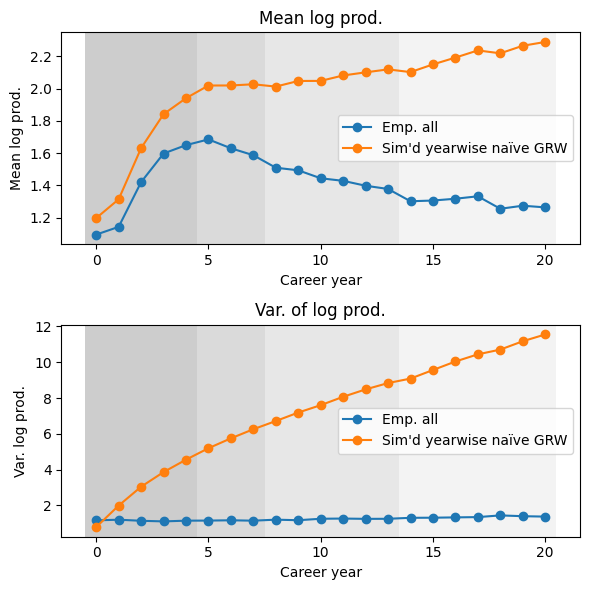

In [45]:
# Cell 12A: yearwise log distribution diagnostics

years = np.arange(0, Y + 1)

emp_year_stats = []
for t in years:
    subset = working_df[working_df["CareerAge"] == t]
    q = subset["pubs_adj"].dropna()
    log_q = np.log(q + EPS)

    q_pos = q[q > 0]
    log_q_pos = np.log(q_pos)

    emp_year_stats.append({
        "year": t,
        "n": len(q),
        "frac_zero": (q == 0).mean(),
        "mean_prod": q.mean(),
        "median_prod": q.median(),
        "mean_log_prod": log_q.mean(),
        "var_log_prod": log_q.var(ddof=0),
        "mean_log_prod_pos": log_q_pos.mean(),
        "var_log_prod_pos": log_q_pos.var(ddof=0),
        "q25_prod": q.quantile(0.25),
        "q50_prod": q.quantile(0.50),
        "q75_prod": q.quantile(0.75),
        "q90_prod": q.quantile(0.90),
        "q95_prod": q.quantile(0.95),
    })

emp_year_stats = pd.DataFrame(emp_year_stats)

sim_year_stats = []
for t in years:
    q = pd.Series(trajs_year_naive[t])
    log_q = np.log(q + EPS)

    sim_year_stats.append({
        "year": t,
        "n": len(q),
        "frac_zero": (q == 0).mean(),
        "mean_prod": q.mean(),
        "median_prod": q.median(),
        "mean_log_prod": log_q.mean(),
        "var_log_prod": log_q.var(ddof=0),
        "q25_prod": q.quantile(0.25),
        "q50_prod": q.quantile(0.50),
        "q75_prod": q.quantile(0.75),
        "q90_prod": q.quantile(0.90),
        "q95_prod": q.quantile(0.95),
    })

sim_year_stats = pd.DataFrame(sim_year_stats)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            facecolor=shade,
            alpha=0.65,
            zorder=0
        )
        
axes[0].plot(emp_year_stats["year"], emp_year_stats["mean_log_prod"], marker="o", label="Emp. all", zorder = 3)
axes[0].plot(sim_year_stats["year"], sim_year_stats["mean_log_prod"], marker="o", label="Sim'd yearwise naïve GRW", zorder = 3)
axes[0].set_title("Mean log prod.")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Mean log prod.")
axes[0].legend()

axes[1].plot(emp_year_stats["year"], emp_year_stats["var_log_prod"], marker="o", label="Emp. all", zorder = 3)
axes[1].plot(sim_year_stats["year"], sim_year_stats["var_log_prod"], marker="o", label="Sim'd yearwise naïve GRW", zorder = 3)
axes[1].set_title("Var. of log prod.")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Var. log prod.")
axes[1].legend()

plt.tight_layout()

plt.savefig(FIGURES / "naive_grw_y_logCompare.png", dpi=300, bbox_inches="tight")
plt.show()


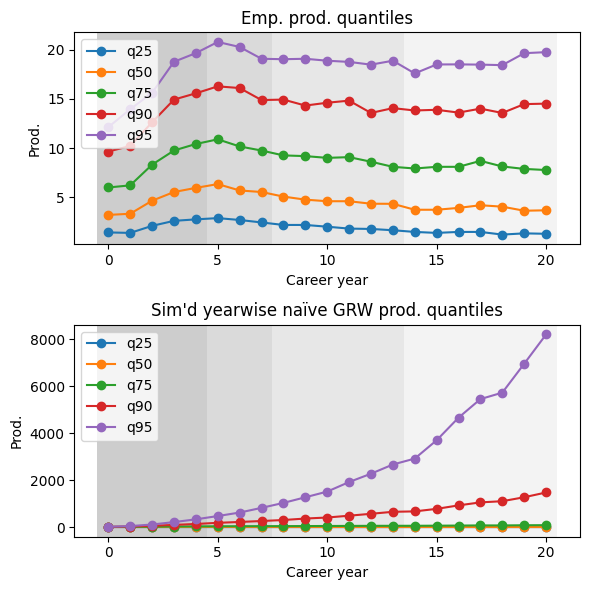

In [46]:
# Cell 12B: yearwise productivity quantile diagnostics

qcols = ["q25_prod", "q50_prod", "q75_prod", "q90_prod", "q95_prod"]

fig, axes = plt.subplots(2, 1, figsize=(6, 6))
for ax in axes:
    for start, end, shade, label in stage_spans:
        ax.axvspan(
            start - 0.5,
            end + 0.5,
            facecolor=shade,
            alpha=0.65,
            zorder=0
        )
for qcol in qcols:
    axes[0].plot(
        emp_year_stats["year"],
        emp_year_stats[qcol],
        marker="o",
        label=qcol.replace("_prod", ""), zorder = 3
    )

axes[0].set_title("Emp. prod. quantiles")
axes[0].set_xlabel("Career year")
axes[0].set_ylabel("Prod.")
axes[0].legend()

for qcol in qcols:
    axes[1].plot(
        sim_year_stats["year"],
        sim_year_stats[qcol],
        marker="o",
        label=qcol.replace("_prod", ""), zorder = 3
    )

axes[1].set_title("Sim'd yearwise naïve GRW prod. quantiles")
axes[1].set_xlabel("Career year")
axes[1].set_ylabel("Prod.")
axes[1].legend()

plt.tight_layout()

plt.savefig(FIGURES / "naive_grw_y_quantiles.png", dpi=300, bbox_inches="tight")
plt.show()


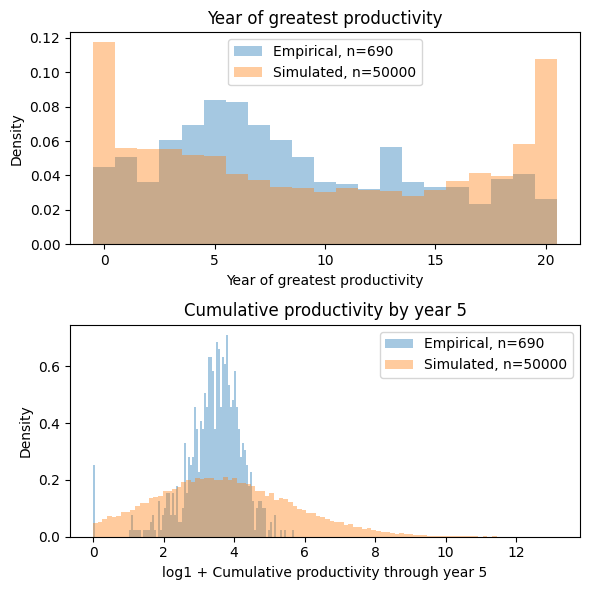

Full empirical trajectories: 690
Simulated trajectories: 50000
KS year of greatest productivity: KstestResult(statistic=np.float64(0.12299043478260874), pvalue=np.float64(1.951325118132169e-09), statistic_location=np.int64(15), statistic_sign=np.int8(1))
KS cumulative productivity by year 5: KstestResult(statistic=np.float64(0.2747168115942029), pvalue=np.float64(6.509533953660591e-46), statistic_location=np.float64(88.926299888939), statistic_sign=np.int8(1))


In [50]:
# Cell 13: dx, norm'd

emp_panel = (
    working_df[working_df["CareerAge"].between(0, Y)]
    .pivot_table(index="dblp_id", columns="CareerAge", values="pubs_adj")
)

emp_panel_full = emp_panel.dropna()

emp_year_max = emp_panel_full.idxmax(axis=1)
emp_cum_y5 = emp_panel_full.loc[:, 0:5].sum(axis=1)

sim_year_max = np.argmax(trajs_year_naive, axis=0)
sim_cum_y5 = trajs_year_naive[0:6, :].sum(axis=0)

ks_year_max = stats.ks_2samp(emp_year_max, sim_year_max)
ks_cum_y5 = stats.ks_2samp(emp_cum_y5, sim_cum_y5)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))

axes[0].hist(
    emp_year_max,
    bins=np.arange(-0.5, Y + 1.5, 1),
    alpha=0.4,
    density=True,
    label=f"Empirical, n={len(emp_year_max)}"
)

axes[0].hist(
    sim_year_max,
    bins=np.arange(-0.5, Y + 1.5, 1),
    alpha=0.4,
    density=True,
    label=f"Simulated, n={len(sim_year_max)}"
)

axes[0].set_xlabel("Year of greatest productivity")
axes[0].set_ylabel("Density")
axes[0].set_title("Year of greatest productivity")
axes[0].legend()

axes[1].hist(
    np.log1p(emp_cum_y5),
    bins=100,
    alpha=0.4,
    density=True,
    label=f"Empirical, n={len(emp_cum_y5)}"
)

axes[1].hist(
    np.log1p(sim_cum_y5),
    bins=100,
    alpha=0.4,
    density=True,
    label=f"Simulated, n={len(sim_cum_y5)}"
)

axes[1].set_xlabel("log1 + Cumulative productivity through year 5")
axes[1].set_ylabel("Density")
axes[1].set_title("Cumulative productivity by year 5")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES / "naive_grw_y_randomWalkDiagnostics.png", dpi=300, bbox_inches="tight")
plt.show()

print("Full empirical trajectories:", len(emp_panel_full))
print("Simulated trajectories:", trajs_year_naive.shape[1])
print("KS year of greatest productivity:", ks_year_max)
print("KS cumulative productivity by year 5:", ks_cum_y5)


In [48]:
# Cell 14: numerical summary

summary = {
    "empirical_mean_y0": emp_mean.loc[0],
    "empirical_mean_y5": emp_mean.loc[5],
    "empirical_mean_y10": emp_mean.loc[10],
    "empirical_mean_y20": emp_mean.loc[20],
    "simulated_mean_y0": sim_mean[0],
    "simulated_mean_y5": sim_mean[5],
    "simulated_mean_y10": sim_mean[10],
    "simulated_mean_y20": sim_mean[20],
    "empirical_median_y0": emp_median.loc[0],
    "empirical_median_y5": emp_median.loc[5],
    "empirical_median_y10": emp_median.loc[10],
    "empirical_median_y20": emp_median.loc[20],
    "simulated_median_y0": sim_median[0],
    "simulated_median_y5": sim_median[5],
    "simulated_median_y10": sim_median[10],
    "simulated_median_y20": sim_median[20],
    "simulated_y20_q95": np.quantile(trajs_year_naive[20], 0.95),
    "simulated_y20_q99": np.quantile(trajs_year_naive[20], 0.99),
    "simulated_y20_max": np.max(trajs_year_naive[20]),
    "ks_year_max_stat": ks_year_max.statistic,
    "ks_year_max_p": ks_year_max.pvalue,
    "ks_cum_y5_stat": ks_cum_y5.statistic,
    "ks_cum_y5_p": ks_cum_y5.pvalue,
}

summary_df = pd.DataFrame([summary])

print("Yearwise log-prod params")
display(year_logprod_params)

print("Yearwise naive log-delta params")
display(year_delta_params)

print("Summary")
display(summary_df)


Yearwise log-prod params


,year,n,mean_log_productivity,var_log_productivity,sd_log_productivity
0,0,2069,1.096164,1.169240,1.081314
1,1,2149,1.143948,1.206474,1.098396
2,2,2208,1.420733,1.146156,1.070587
3,3,2252,1.597963,1.111421,1.054239
4,4,2283,1.649832,1.152084,1.073352
5,5,2277,1.685266,1.157075,1.075674
6,6,2214,1.630428,1.173957,1.083493
7,7,2156,1.587435,1.151704,1.073175
8,8,2074,1.510005,1.208534,1.099334
9,9,1992,1.494018,1.177235,1.085005


Yearwise naive log-delta params


,year,n,mean_log_delta,sigma_log_delta,var_log_delta,sample_mean_log_delta,sample_sd_log_delta
0,0,2067,0.028980,1.259683,1.586803,0.028980,1.259683
1,1,2143,0.268758,1.196293,1.431118,0.268758,1.196293
2,2,2202,0.173335,1.081619,1.169899,0.173335,1.081619
3,3,2247,0.051549,1.050041,1.102587,0.051549,1.050041
4,4,2259,0.027380,1.044818,1.091644,0.027380,1.044818
5,5,2200,-0.063831,1.057698,1.118724,-0.063831,1.057698
6,6,2142,-0.053350,1.014904,1.030030,-0.053350,1.014904
7,7,2059,-0.089495,1.043648,1.089201,-0.089495,1.043648
8,8,1985,-0.025281,1.031750,1.064507,-0.025281,1.031750
9,9,1895,-0.060497,1.019692,1.039773,-0.060497,1.019692


Summary


,empirical_mean_y0,empirical_mean_y5,empirical_mean_y10,empirical_mean_y20,simulated_mean_y0,simulated_mean_y5,simulated_mean_y10,simulated_mean_y20,empirical_median_y0,empirical_median_y5,...,simulated_median_y5,simulated_median_y10,simulated_median_y20,simulated_y20_q95,simulated_y20_q99,simulated_y20_max,ks_year_max_stat,ks_year_max_p,ks_cum_y5_stat,ks_cum_y5_p
0,4.304679,7.729319,6.428626,5.797863,4.312892,197.213371,1745.819328,100554.28116,3.225469,6.352937,...,5.377416,3.759466,2.833233,8202.026661,216803.616289,2.698509e+09,0.12299,1.951325e-09,0.274717,6.509534e-46


In [49]:
# Cell 15: save outputs

year_logprod_params.to_csv(RESULTS / "naive_grw_y_yearLogProdParams.csv", index=False)
year_delta_params.to_csv(RESULTS / "naive_grw_y_yearDeltaParams.csv", index=False)
global_delta_params.to_csv(RESULTS / "naive_grw_y_globalDeltaParams.csv", index=False)
emp_year_stats.to_csv(RESULTS / "naive_grw_y_empYearStats.csv", index=False)
sim_year_stats.to_csv(RESULTS / "naive_grw_y_simYearStats.csv", index=False)
summary_df.to_csv(RESULTS / "naive_grw_y_Summary.csv", index=False)

with open(RESULTS / "year_log_naive_report.txt", "w") as f:
    f.write("Naïve-GRW-Y report\n")
    f.write("\n\n")

    f.write("Model\n")
    f.write("\n")
    f.write("z_{t+1} = z_t + error_t\n")
    f.write("where z_t = log(pubs_adj_t + EPS).\n")
    f.write("error_t ~ Normal(mean_log_delta_t, sigma_log_delta_t^2).\n\n")

    f.write(f"EPS = {EPS}\n")
    f.write(f"N = {N}\n")
    f.write(f"Y = {Y}\n\n")

    f.write("Yearwise log-productivity parameters\n")
    f.write("\n")
    f.write(year_logprod_params.to_string(index=False))

    f.write("\n\nYearwise naive log-delta parameters\n")
    f.write("\n")
    f.write(year_delta_params.to_string(index=False))

    f.write("\n\nGlobal naive log-delta parameters\n")
    f.write("\n")
    f.write(global_delta_params.to_string(index=False))

    f.write("\n\nsummary\n")
    f.write("-------\n")
    f.write(summary_df.to_string(index=False))
